# Team members

* ID: 0001215190 - Şimal Yücel - simal.yucel@studio.unibo.it
* ID: 0001241443 - Davide Tonelli - davide.tonelli8@studio.unibo.it
* ID: 0001230674 - Giovanni Stea - giovanni.stea@studio.unibo.it

# Assignment Module 1 — Coin Detection and Counting: Solution

Given a reference image for each euro denomination and 142 target photographs,
the goal is to detect every coin in each target image, recognise its denomination
and report the monetary amount per image together with the grand total.

The solution below is a classical computer-vision pipeline organised in four stages:

1. **Detection** — candidate circles from the Hough transform, run on two image
   channels, followed by geometric and photometric plausibility filters.
2. **Colour description** — CIELab statistics of each candidate disc: metal hue,
   chroma, and a centre-vs-ring structure test for the bimetallic 1€/2€ coins.
3. **Appearance description** — a rotation-invariant polar correlation against the
   reference coins.
4. **Joint classification** — a per-image *scale consensus*: every denomination
   hypothesis for every coin votes for the mm-per-pixel scale of the photograph,
   and the scale that best explains the whole image assigns the final labels.

Monetary values are handled in integer cents everywhere and converted to euros
only for display.

## 0. Setup

In [18]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

REF_DIR = "coin_dataset/reference_set"
TARGET_DIR = "coin_dataset/target_set"
N_TARGETS = 142

# Official euro coin data: value in cents, metal family, diameter in mm.
COIN_INFO = {
    "1cent":  {"value": 1,   "family": "copper",  "diameter": 16.25},
    "2cent":  {"value": 2,   "family": "copper",  "diameter": 18.75},
    "5cent":  {"value": 5,   "family": "copper",  "diameter": 21.25},
    "10cent": {"value": 10,  "family": "gold",    "diameter": 19.75},
    "20cent": {"value": 20,  "family": "gold",    "diameter": 22.25},
    "50cent": {"value": 50,  "family": "gold",    "diameter": 24.25},
    "1euro":  {"value": 100, "family": "bimetal", "diameter": 23.25},
    "2euro":  {"value": 200, "family": "bimetal", "diameter": 25.75},
}
COIN_NAMES = list(COIN_INFO)

pd.DataFrame(COIN_INFO).T

,value,family,diameter
1cent,1,copper,16.25
2cent,2,copper,18.75
5cent,5,copper,21.25
10cent,10,gold,19.75
20cent,20,gold,22.25
50cent,50,gold,24.25
1euro,100,bimetal,23.25
2euro,200,bimetal,25.75


### 0.0 Getting the dataset

When the notebook runs in an environment where `coin_dataset/` is not already present (e.g. Google Colab), the following cell downloads the archive from Google Drive and unzips it. If the dataset folders already exist, the cell only verifies them and does nothing else.

In [19]:
import os
import zipfile

# Google Drive file id of coin_dataset.zip, taken from the share link:
# https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
GDRIVE_FILE_ID = "1m9kbSHJojKS7Bc_WZIMnqsMm4GbhDcFq"
ZIP_NAME = "coin_dataset.zip"

if not (os.path.isdir(REF_DIR) and os.path.isdir(TARGET_DIR)):
    try:
        import gdown
    except ImportError:
        %pip install -q gdown
        import gdown

    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_NAME, quiet=False)

    with zipfile.ZipFile(ZIP_NAME) as zf:
        # the archive may contain the coin_dataset folder itself or its two
        # subfolders directly at the root: extract accordingly
        roots = {name.split("/")[0] for name in zf.namelist()}
        zf.extractall("." if "coin_dataset" in roots else "coin_dataset")
    os.remove(ZIP_NAME)

assert os.path.isdir(REF_DIR), f"missing {REF_DIR} after extraction"
assert os.path.isdir(TARGET_DIR), f"missing {TARGET_DIR} after extraction"
print("reference images:", len(os.listdir(REF_DIR)))
print("target images:   ", len(os.listdir(TARGET_DIR)))

reference images: 8
target images:    142


## 0.1 Loading the images

`cv2.imread` always returns pixel data in **BGR** order, so the natural loading
recipe is `imread` followed by `cv2.COLOR_BGR2RGB`. Before trusting that we verify it on both image sets, because a mistake here silently corrupts every
colour measurement downstream.

The check is the following: euro coins are made of copper- and brass-coloured alloys, so inside a coin the **red channel must dominate the blue channel**. We measure the central patch of one reference image and of one detected coin in a target image.

In [20]:
def imread_raw(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return img

# central patch of the 50 cent reference (a gold coin fills the frame centre)
ref_raw = imread_raw(f"{REF_DIR}/50cent.jpg")
h, w = ref_raw.shape[:2]
patch = ref_raw[h//2 - 50:h//2 + 50, w//2 - 50:w//2 + 50]
print("reference 50cent, centre patch, channel means (imread order):",
      patch.reshape(-1, 3).mean(axis=0).round(1))

# same measurement on a target photograph (image_81 shows a single coin
# roughly at the image centre)
tgt_raw = imread_raw(f"{TARGET_DIR}/image_81.jpg")
h, w = tgt_raw.shape[:2]
patch = tgt_raw[h//2 - 40:h//2 + 40, w//2 - 40:w//2 + 40]
print("target image_81,  centre patch, channel means (imread order):",
      patch.reshape(-1, 3).mean(axis=0).round(1))

reference 50cent, centre patch, channel means (imread order): [ 46.7  69.2 105.4]
target image_81,  centre patch, channel means (imread order): [184.4 167.1  98.3]


The reference behaves as expected: the last channel (R in BGR order) dominates. The target image shows the **opposite** pattern: the first channel dominates. Since a euro coin cannot be blue, the target JPEGs must have been saved with their channels already reversed: for the target set, `imread` effectively returns **RGB** data directly.

We therefore use two different loaders and keep everything in true RGB from here
on. This asymmetry is a property of the dataset files themselves, and getting it
wrong would flip copper into cyan and break the whole colour analysis.

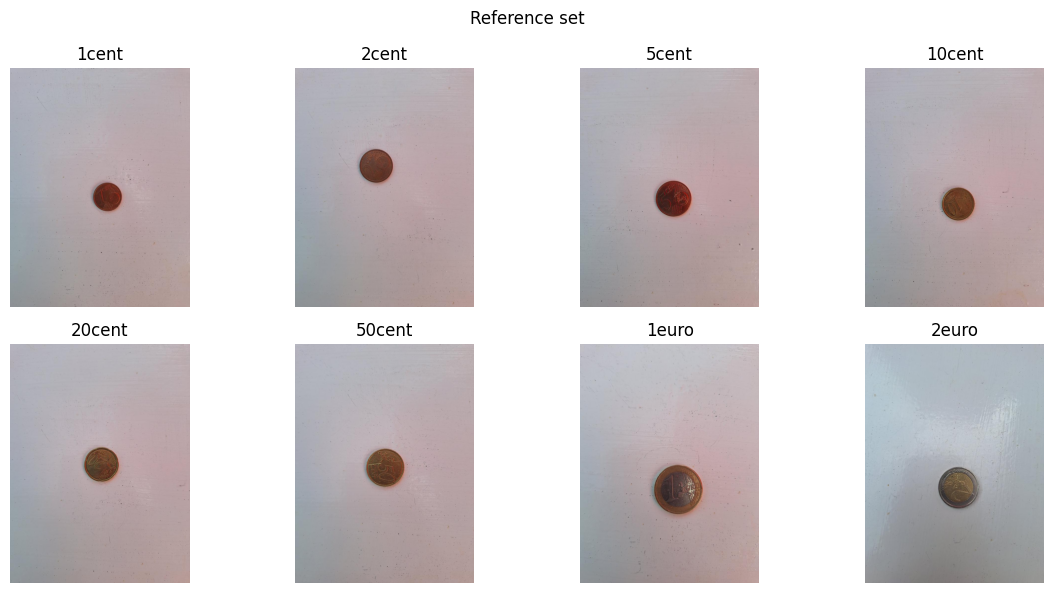

In [21]:
def load_reference(name):
    """Reference JPEGs are standard files: imread gives BGR, convert to RGB."""
    return cv2.cvtColor(imread_raw(f"{REF_DIR}/{name}.jpg"), cv2.COLOR_BGR2RGB)

def load_target(idx):
    """Target JPEGs are stored with reversed channels: imread already gives RGB."""
    return imread_raw(f"{TARGET_DIR}/image_{idx}.jpg")

reference_images = {name: load_reference(name) for name in COIN_NAMES}
target_images = {idx: load_target(idx) for idx in range(1, N_TARGETS + 1)}

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for ax, (name, img) in zip(axs.flat, reference_images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
fig.suptitle("Reference set")
plt.tight_layout()
plt.show()

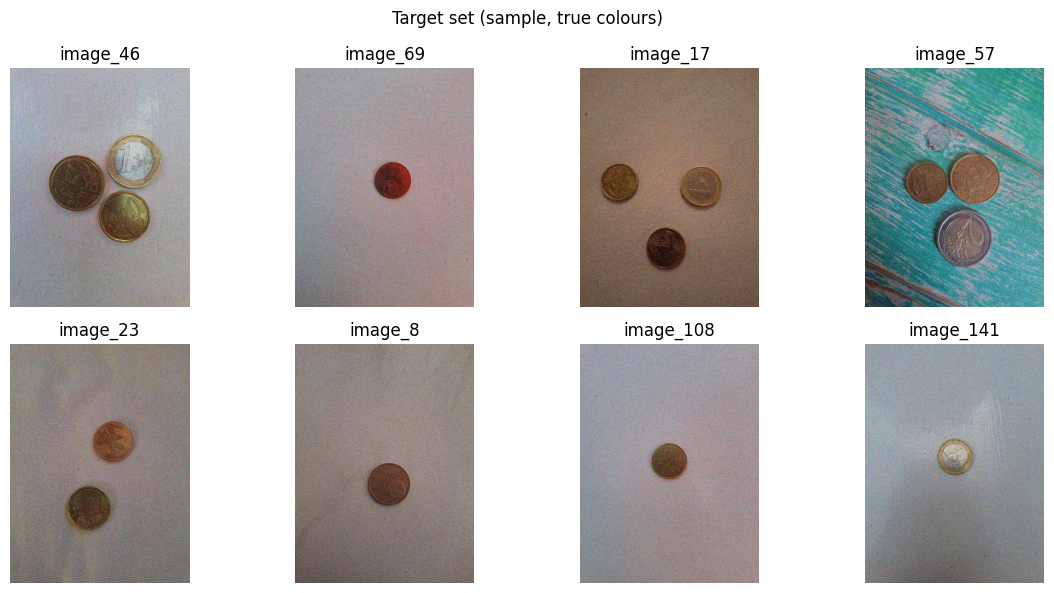

In [22]:
sample_idxs = np.random.choice(range(1, N_TARGETS + 1), size=8, replace=False)

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axs.flat, sample_idxs):
    ax.imshow(target_images[idx])
    ax.set_title(f"image_{idx}")
    ax.axis("off")
fig.suptitle("Target set (sample, true colours)")
plt.tight_layout()
plt.show()

The target photographs are noisy, taken at different distances and under very
different illuminations, and a few contain distracting or cluttered backgrounds. These observations drive the design choices below.

## 1. Coin detection

Coins photographed roughly frontally appear as circles, so candidate coins are
found with the **circular Hough transform** (`cv2.HoughCircles`).
The raw transform alone is not reliable enough on this data, so the detector is
built as a small cascade:

1. **Pre-smoothing.** A median filter (radius suited to the impulse noise present
   in several photos) followed by a Gaussian blur. `HoughCircles` runs its own
   Canny edge extraction internally, so the goal here is only to suppress noise
   while keeping the coin rims sharp enough.
2. **Primary pass on luminance** with a conservative accumulator threshold.
3. **Duplicate suppression.** Hough returns candidates ordered by accumulator
   support; a candidate whose centre falls inside an already accepted circle is
   discarded.
4. **Secondary pass on the blue channel.** Copper and brass reflect little blue
   light, so coins are consistently *dark* in the blue channel regardless of how
   washed-out they look in luminance. A candidate from this pass is accepted only if its interior really is darker than its surroundings (verified directly on the blue channel), which keeps the pass from hallucinating circles on textured backgrounds.
5. **Physical size consistency.** Euro diameters span only a factor 1.585
   (16.25 mm to 25.75 mm). Within one photo all coins share the camera distance,
   so the ratio between the largest and smallest true coin radius is bounded; we
   keep the largest subset of candidates compatible with that bound (with margin
   for perspective).
6. **Fallback.** If nothing survives, the accumulator threshold is relaxed
   step by step: better a weak candidate than a missed image.

In [23]:
MAX_RADIUS_RATIO = 1.9       # 1.585 physical ratio + perspective margin
BLUE_DARKNESS_MIN = 0.22     # relative darkness required by the blue-channel pass


def smooth_for_hough(channel):
    return cv2.GaussianBlur(cv2.medianBlur(channel, 5), (0, 0), sigmaX=2.0)


def hough_candidates(smoothed, accumulator_threshold):
    found = cv2.HoughCircles(
        smoothed, cv2.HOUGH_GRADIENT,
        dp=1.5, minDist=70,
        param1=80, param2=accumulator_threshold,
        minRadius=28, maxRadius=160,
    )
    return [] if found is None else [tuple(map(float, c)) for c in found[0]]


def drop_duplicates(circles):
    """Keep the strongest circle when centres collide (list arrives strongest-first)."""
    kept = []
    for x, y, r in circles:
        if all((x - kx) ** 2 + (y - ky) ** 2 > (0.8 * kr) ** 2 for kx, ky, kr in kept):
            kept.append((x, y, r))
    return kept


def size_consistent_subset(circles):
    """Largest subset whose radii can all be euro coins seen from one distance."""
    if len(circles) <= 1:
        return circles
    best = []
    for _, _, anchor in circles:
        subset = [c for c in circles if anchor <= c[2] <= anchor * MAX_RADIUS_RATIO]
        better = len(subset) > len(best) or (
            len(subset) == len(best) and sum(c[2] for c in subset) > sum(c[2] for c in best))
        if better:
            best = subset
    return best


def blue_darkness(blue, x, y, r):
    """How much darker the disc is than its surroundings, in the blue channel."""
    h, w = blue.shape
    yy, xx = np.mgrid[0:h, 0:w]
    d = np.sqrt((xx - x) ** 2 + (yy - y) ** 2) / r
    inner = np.median(blue[d < 0.85].astype(float))
    outer = np.median(blue[(d > 1.15) & (d < 1.5)].astype(float))
    return (outer - inner) / max(outer, 1.0)


def detect_coins(rgb):
    luminance = smooth_for_hough(cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY))
    blue = rgb[:, :, 2]

    circles = drop_duplicates(hough_candidates(luminance, 40))
    for x, y, r in drop_duplicates(hough_candidates(smooth_for_hough(blue), 40)):
        far_from_known = all(
            (x - ax) ** 2 + (y - ay) ** 2 > (0.9 * max(r, ar)) ** 2
            for ax, ay, ar in circles)
        if far_from_known and blue_darkness(blue, x, y, r) >= BLUE_DARKNESS_MIN:
            circles.append((x, y, r))

    circles = size_consistent_subset(circles)
    if circles:
        return circles

    for relaxed in (32, 25, 18):
        circles = size_consistent_subset(drop_duplicates(hough_candidates(luminance, relaxed)))
        if circles:
            return circles
    return []

In [24]:
detections = {idx: detect_coins(img) for idx, img in target_images.items()}

counts = pd.Series({idx: len(c) for idx, c in detections.items()})
print("coins per image:")
print(counts.value_counts().sort_index().rename("images").to_string())
print(f"total detections: {counts.sum()}")

coins per image:
1    55
2    28
3    38
4     8
5     2
6     5
7     4
8     2
total detections: 341


In [25]:
fig, axs = plt.subplots(3, 5, figsize=(16, 12))
show_idxs = np.random.choice(range(1, N_TARGETS + 1), size=15, replace=False)
for ax, idx in zip(axs.flat, show_idxs):
    canvas = target_images[idx].copy()
    for x, y, r in detections[idx]:
        cv2.circle(canvas, (int(x), int(y)), int(r), (0, 255, 0), 4)
    ax.imshow(canvas)
    ax.set_title(f"image_{idx}: {len(detections[idx])}")
    ax.axis("off")
fig.suptitle("Detection examples")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Detection as we arranged it is intentionally slightly permissive: a few background objects may still get through. Instead of trying to make the detector perfect, the pipeline follows a *propose-then-verify* philosophy, i.e. the classification stage measures colour and size evidence for every candidate and is allowed to **reject** candidates that cannot be explained as a euro coin.

## 2. Colour description in CIELab

Colour is measured in **CIELab**, where the two chromatic axes (a\*, b\*) are
independent of lightness. For every candidate disc we compute:

* the median (a\*, b\*) of the whole disc, of the **central region** (< 0.45 r)
  and of an **outer ring** (0.65–0.92 r);
* the **hue angle** and **chroma** of the disc after a *capped white-balance
  correction*: the median background colour is subtracted, but the correction is
  limited in magnitude, so a mild illumination cast is compensated while a
  genuinely coloured background cannot drag the coin colour away;
* a **bimetal structure test**: 1€ and 2€ coins combine a brass part (strongly
  chromatic) with a nickel part (nearly grey). A large chroma difference
  between centre and ring, with one of the two parts close to grey, identifies
  a bimetallic coin, and the *sign* of the difference tells the two apart
  (1€: grey centre / brass ring, 2€: brass centre / grey ring). Being a
  within-coin contrast, this test is remarkably robust to illumination;
* two background-similarity measures (chromatic distance and lightness
  difference between disc and background) used later to reject candidates that
  are simply patches of background.

In [26]:
WB_CAP = 12.0   # maximum magnitude of the background-based white-balance shift


def colour_features(rgb, circles):
    lab = cv2.cvtColor(cv2.medianBlur(rgb, 5), cv2.COLOR_RGB2Lab).astype(np.float32)
    lab[:, :, 1:] -= 128.0  # centre the chromatic axes
    h, w = lab.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w]

    outside = np.ones((h, w), bool)
    for x, y, r in circles:
        outside &= ((xx - x) ** 2 + (yy - y) ** 2) >= (1.3 * r) ** 2
    bg_ab = np.array([np.median(lab[outside, 1]), np.median(lab[outside, 2])])
    bg_light = float(np.median(lab[outside, 0]))
    magnitude = np.linalg.norm(bg_ab)
    wb_shift = bg_ab if magnitude <= WB_CAP else bg_ab * (WB_CAP / magnitude)

    feats = []
    for x, y, r in circles:
        d = np.sqrt((xx - x) ** 2 + (yy - y) ** 2) / r
        centre, ring, disc = d < 0.45, (d > 0.65) & (d < 0.92), d < 0.92
        ca, cb = np.median(lab[centre, 1]), np.median(lab[centre, 2])
        ra, rb = np.median(lab[ring, 1]), np.median(lab[ring, 2])
        da, db = np.median(lab[disc, 1]), np.median(lab[disc, 2])
        wa, wb_ = da - wb_shift[0], db - wb_shift[1]
        feats.append({
            "hue": float(np.degrees(np.arctan2(wb_, wa)) % 360),
            "chroma": float(np.hypot(wa, wb_)),
            "centre_chroma": float(np.hypot(ca, cb)),
            "ring_chroma": float(np.hypot(ra, rb)),
            "bimetal_contrast": float(np.hypot(ca - ra, cb - rb)),
            "bimetal_signed": float(np.hypot(ca, cb) - np.hypot(ra, rb)),
            "bg_colour_distance": float(np.hypot(da - bg_ab[0], db - bg_ab[1])),
            "bg_lightness_diff": float(abs(np.median(lab[disc, 0]) - bg_light)),
        })
    return feats


target_features = {idx: colour_features(img, detections[idx])
                   for idx, img in target_images.items()}

reference_circle = {}
reference_colour = {}
for name, img in reference_images.items():
    circle = max(detect_coins(img), key=lambda c: c[2])
    reference_circle[name] = circle
    reference_colour[name] = colour_features(img, [circle])[0]

pd.DataFrame(reference_colour).T[
    ["hue", "chroma", "bimetal_contrast", "bimetal_signed"]].round(1)

,hue,chroma,bimetal_contrast,bimetal_signed
1cent,46.5,27.6,2.2,-2.2
2cent,53.1,20.0,1.4,-1.4
5cent,41.8,25.5,5.7,-5.6
10cent,64.4,25.5,1.4,1.4
20cent,68.2,21.5,1.4,-0.3
50cent,66.8,22.8,1.4,-0.3
1euro,61.4,12.5,14.3,-13.4
2euro,74.5,18.7,12.0,11.5


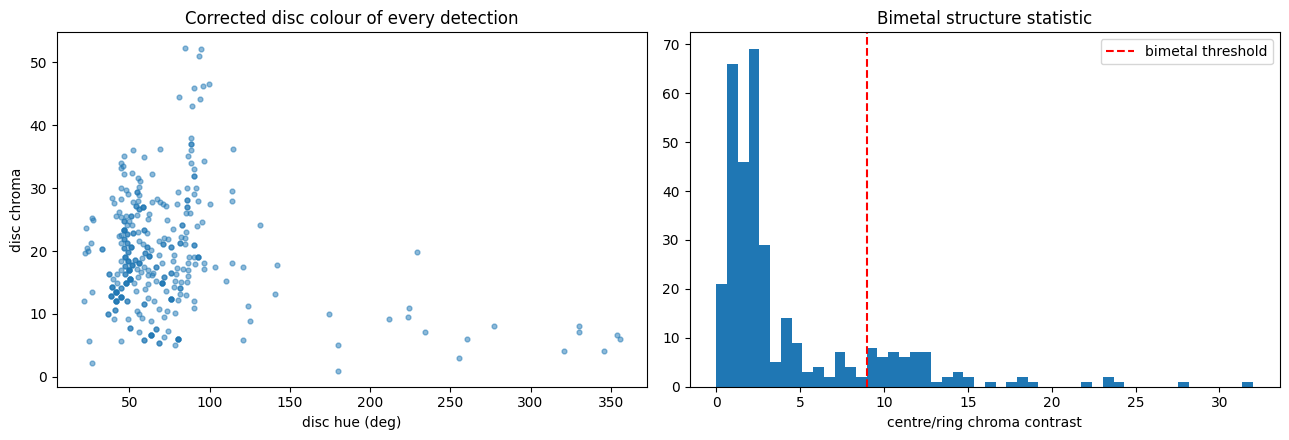

In [27]:
all_feats = [f for feats in target_features.values() for f in feats]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
axs[0].scatter([f["hue"] for f in all_feats], [f["chroma"] for f in all_feats],
               s=12, alpha=0.5)
axs[0].set_xlabel("disc hue (deg)"); axs[0].set_ylabel("disc chroma")
axs[0].set_title("Corrected disc colour of every detection")
axs[1].hist([f["bimetal_contrast"] for f in all_feats], bins=50)
axs[1].axvline(9.0, color="red", ls="--", label="bimetal threshold")
axs[1].set_xlabel("centre/ring chroma contrast"); axs[1].legend()
axs[1].set_title("Bimetal structure statistic")
plt.tight_layout()
plt.show()

On the reference set the copper coins sit at hue around 40-50°, the Nordic-gold coins around 60-70°, and the two bimetallic coins produce a large centre/ring contrast with opposite signs: exactly the behaviour the classifier relies on. On the target set the same clusters are visible but heavily smeared by illumination, which is why hue enters the classifier as *soft evidence* (a wide Gaussian weight per family) rather than a hard decision.

## 3. Rotation-invariant appearance descriptor

Engravings can in principle separate coins of the same metal, so we also compare
each candidate with the reference coins. A coin can lie in any orientation, so
the comparison must be rotation invariant: each disc is unwarped into **polar
coordinates** (angle x radius), contrast-normalised with CLAHE, standardised per
radius, and two coins are compared by the maximum of their **circular
cross-correlation** over all angular shifts, which is computed in one step with an FFT along the angle axis.

We then run a sanity check below which verifies that a coin matched against a rotated copy of itself scores highly while different references stay well separated. On the blurred, noisy target coins this descriptor is much weaker, so it receives only a small weight in the final decision: it acts as a tie-breaker and not as a main cue.

In [28]:
POLAR_ANGLES, POLAR_RADII, INNER_SKIP = 180, 48, 0.15
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def polar_signature(gray, x, y, r):
    polar = cv2.warpPolar(gray, (POLAR_RADII, POLAR_ANGLES), (float(x), float(y)),
                          float(r * 0.95), cv2.WARP_POLAR_LINEAR | cv2.INTER_LINEAR)
    polar = polar[:, int(INNER_SKIP * POLAR_RADII):]  # drop the distorted core
    polar = clahe.apply(polar.astype(np.uint8)).astype(np.float32)
    polar -= polar.mean(axis=0, keepdims=True)  # per-radius standardisation
    polar /= polar.std(axis=0, keepdims=True) + 1e-6
    return polar


def circular_correlation(sig_a, sig_b):
    """Max normalised cross-correlation over all cyclic angular shifts (via FFT)."""
    spectrum = np.fft.rfft(sig_a, axis=0) * np.conj(np.fft.rfft(sig_b, axis=0))
    corr = np.fft.irfft(spectrum, n=sig_a.shape[0], axis=0).sum(axis=1)
    return float(corr.max() / (np.linalg.norm(sig_a) * np.linalg.norm(sig_b) + 1e-9))


reference_signature = {}
for name, img in reference_images.items():
    x, y, r = reference_circle[name]
    reference_signature[name] = polar_signature(
        cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), x, y, r)


# Check on rotation invariance and reference separation
gray = cv2.cvtColor(reference_images["50cent"], cv2.COLOR_RGB2GRAY)
x, y, r = reference_circle["50cent"]
M = cv2.getRotationMatrix2D((x, y), 73.0, 1.0)
rotated = cv2.warpAffine(gray, M, gray.shape[::-1])
self_score = circular_correlation(
    reference_signature["50cent"], polar_signature(rotated, x, y, r))
print(f"50cent vs itself rotated by 73 deg: {self_score:.3f}")

cross = pd.DataFrame(
    {a: {b: circular_correlation(reference_signature[a], reference_signature[b])
         for b in COIN_NAMES} for a in COIN_NAMES})
cross.round(2)

50cent vs itself rotated by 73 deg: 0.835


,1cent,2cent,5cent,10cent,20cent,50cent,1euro,2euro
1cent,1.00,0.19,0.14,0.12,0.08,0.11,0.11,0.10
2cent,0.19,1.00,0.20,0.07,0.13,0.18,0.26,0.21
5cent,0.14,0.20,1.00,0.06,0.13,0.13,0.24,0.19
10cent,0.12,0.07,0.06,1.00,0.07,0.13,0.10,0.07
20cent,0.08,0.13,0.13,0.07,1.00,0.14,0.19,0.12
50cent,0.11,0.18,0.13,0.13,0.14,1.00,0.17,0.15
1euro,0.11,0.26,0.24,0.10,0.19,0.17,1.00,0.24
2euro,0.10,0.21,0.19,0.07,0.12,0.15,0.24,1.00


In [29]:
target_polar = {}
for idx, img in target_images.items():
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    target_polar[idx] = [
        {name: circular_correlation(polar_signature(gray, x, y, r),
                                    reference_signature[name])
         for name in COIN_NAMES}
        for x, y, r in detections[idx]]

## 4. Classification by per-image scale consensus

The single most discriminative property left is **physical size**, but a pixel
radius means nothing until the mm-per-pixel scale of the photo is known, and the
scale differs between photos. The key idea is that *every coin in an image shares one scale*, so instead of classifying coins independently we let all of them vote.

For a candidate scale $s$ and coin $i$ with radius $r_i$, each denomination $d$
(diameter $D_d$) explains the coin with likelihood

$$ L_i(d \mid s) \;=\; w_i(d)\,\exp\!\left(-\tfrac{1}{2}\left(\frac{\log r_i - \log (s D_d / 2)}{\sigma}\right)^{\!2}\right), $$

where $w_i(d)$ is the scale-free compatibility of coin $i$ with denomination $d$:

* a bimetallic candidate strongly prefers 1€ or 2€ according to the sign of its
  centre/ring contrast;
* a single-metal candidate weighs the copper and gold families with a wide
  Gaussian on its corrected hue;
* the polar appearance score slightly modulates the weight.

The image scale is then chosen by maximising
$\sum_i \log \max_d L_i(d \mid s)$ over a grid of scales, with a weak prior on
$s$ learnt from the plausible range of the dataset. At the winning scale each
coin takes its best denomination. Images with several coins, or with one
bimetallic coin, whose denomination pins the scale exactly, benefit the most;
for a lone single-metal coin the decision honestly degrades to colour + prior.

Two rejection rules run inside the classifier are:

* a candidate whose disc matches the background in both chromaticity **and**
  lightness (and shows no bimetal structure) is a background patch, not a coin;
* a candidate whose best final likelihood stays below a minimum is dropped as
  unexplainable.

In [30]:
HUE_MODELS = {"copper": (45.0, 13.0), "gold": (70.0, 15.0)}   # (mean deg, sigma)
HUE_FLOOR = 0.10
CROSS_FAMILY_WEIGHT = 0.10      # bimetal candidate considered as single-metal
NON_BIMETAL_WEIGHT = 0.08       # single-metal candidate considered as 1/2 euro
WRONG_EURO_WEIGHT = 0.08
BIMETAL_MIN_CONTRAST = 9.0
BIMETAL_MIN_CHROMA = 7.5        # the brass part must be visibly chromatic
BIMETAL_MAX_GREY_CHROMA = 12.0  # the nickel part must be close to grey
BG_COLOUR_DISTANCE_MIN = 6.0
BG_LIGHTNESS_DIFF_MIN = 12.0
LOG_RADIUS_SIGMA = 0.07
SCALE_GRID = np.linspace(np.log(3.5), np.log(15.0), 120)  # log(px per mm)
SCALE_PRIOR_MEAN, SCALE_PRIOR_SIGMA = np.log(7.0), 0.45
POLAR_WEIGHT = 0.15
MIN_ACCEPT_SCORE = 0.06


def hue_weight(family, hue):
    mean, sigma = HUE_MODELS[family]
    delta = (hue - mean + 180.0) % 360.0 - 180.0  # circular difference
    return HUE_FLOOR + (1 - HUE_FLOOR) * float(np.exp(-0.5 * (delta / sigma) ** 2))


def is_bimetal(f):
    return (f["bimetal_contrast"] >= BIMETAL_MIN_CONTRAST and
            max(f["centre_chroma"], f["ring_chroma"]) >= BIMETAL_MIN_CHROMA and
            min(f["centre_chroma"], f["ring_chroma"]) <= BIMETAL_MAX_GREY_CHROMA)


def looks_like_background(f):
    return (f["bg_colour_distance"] < BG_COLOUR_DISTANCE_MIN and
            f["bg_lightness_diff"] < BG_LIGHTNESS_DIFF_MIN and
            not is_bimetal(f))


def denomination_weights(f, polar):
    """Scale-free compatibility of one candidate with each denomination."""
    polar_values = np.array([polar[name] for name in COIN_NAMES])
    spread = polar_values.max() - polar_values.min() + 1e-9
    polar_norm = (polar_values - polar_values.min()) / spread

    weights = np.empty(len(COIN_NAMES))
    for j, name in enumerate(COIN_NAMES):
        family = COIN_INFO[name]["family"]
        if is_bimetal(f):
            if family != "bimetal":
                w = CROSS_FAMILY_WEIGHT
            else:
                sign_says_1euro = f["bimetal_signed"] < 0  # grey centre, brass ring
                w = 1.0 if (name == "1euro") == sign_says_1euro else WRONG_EURO_WEIGHT
        else:
            w = NON_BIMETAL_WEIGHT if family == "bimetal" else hue_weight(family, f["hue"])
        weights[j] = w * (1 - POLAR_WEIGHT + POLAR_WEIGHT * polar_norm[j])
    return weights


def classify_image(circles, feats, polar_scores):
    """Returns (labels, rejections): labels[i] is None when candidate i is rejected."""
    n = len(circles)
    labels = [None] * n
    rejections = [(i, "background") for i in range(n) if looks_like_background(feats[i])]
    kept = [i for i in range(n) if not looks_like_background(feats[i])]
    if not kept:
        return labels, rejections

    weights = np.stack([denomination_weights(feats[i], polar_scores[i]) for i in kept])
    log_radii = np.log([circles[i][2] for i in kept])
    log_half_diam = np.log([COIN_INFO[name]["diameter"] / 2 for name in COIN_NAMES])

    def likelihood(log_scale):
        err = log_radii[:, None] - (log_scale + log_half_diam)[None, :]
        return weights * np.exp(-0.5 * (err / LOG_RADIUS_SIGMA) ** 2)

    def objective(log_scale):
        prior = -0.5 * ((log_scale - SCALE_PRIOR_MEAN) / SCALE_PRIOR_SIGMA) ** 2
        return np.log(likelihood(log_scale).max(axis=1) + 1e-12).sum() + prior

    best_scale = max(SCALE_GRID, key=objective)
    final = likelihood(best_scale)

    for row, i in enumerate(kept):
        order = np.argsort(-final[row])
        top = int(order[0])
        score = float(final[row, top])
        if score < MIN_ACCEPT_SCORE:
            rejections.append((i, "low score"))
            continue
        labels[i] = {
            "label": COIN_NAMES[top],
            "value": COIN_INFO[COIN_NAMES[top]]["value"],
            "score": score,
            "margin": float(final[row, top] - final[row, order[1]]),
            "scale_px_per_mm": float(np.exp(best_scale)),
        }
    return labels, rejections

We finally run our classification routine on all the target images.

In [31]:
classification = {}
for idx in target_images:
    labels, rejections = classify_image(
        detections[idx], target_features[idx], target_polar[idx])
    classification[idx] = {"labels": labels, "rejections": rejections}

rows = []
for idx, out in classification.items():
    for i, label in enumerate(out["labels"]):
        if label is not None:
            rows.append({"image": idx, "candidate": i, **label})
predictions = pd.DataFrame(rows)

n_rejected = sum(len(out["rejections"]) for out in classification.values())
print(f"accepted coins: {len(predictions)}   rejected candidates: {n_rejected}")
print()
print(predictions["label"].value_counts().to_string())

accepted coins: 334   rejected candidates: 7

label
5cent     69
20cent    53
50cent    46
2cent     41
1cent     39
10cent    34
1euro     34
2euro     18


## 5. Results

### 5.1 Textual output

For every target image we print the number of coins found, the value assigned to each coin, and the partial amount, followed by the total over the whole target set.
Values are stored in cents and formatted in euros with three decimals only here.

In [32]:
grand_total_cents = 0

for idx in sorted(target_images):
    labels = [l for l in classification[idx]["labels"] if l is not None]
    partial_cents = sum(l["value"] for l in labels)
    grand_total_cents += partial_cents

    print(f"image_{idx}.jpg - {len(labels)} coin(s) found:")
    for i, l in enumerate(labels, start=1):
        print(f"  Coin {i} {{value: {l['value'] / 100:.3f}}}")
    print(f"  Partial Amount {{value: {partial_cents / 100:.3f}}}")

print(f"Total Amount: {grand_total_cents / 100:.3f} EUR")

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.010}
  Partial Amount {value: 0.080}
image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}
image_3.jpg - 6 coin(s) found:
  Coin 1 {value: 0.020}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.050}
  Coin 4 {value: 0.010}
  Coin 5 {value: 0.010}
  Coin 6 {value: 0.020}
  Partial Amount {value: 0.160}
image_4.jpg - 1 coin(s) found:
  Coin 1 {value: 0.200}
  Partial Amount {value: 0.200}
image_5.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}
image_6.jpg - 1 coin(s) found:
  Coin 1 {value: 0.200}
  Partial Amount {value: 0.200}
image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.500}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.500}
  Partial Amount {value: 1.050}
image_8.jpg - 1 coin(s) found:
  Coin 1 {value: 0.020}
  Partial Amount {value: 0.020}
image_9.jpg - 1 coin(s) found:
  Coin 1 {value: 0.050}
  Partial Amount {value: 0.050}
i

### 5.2 Per-image summary and confidence

`score` is the winning likelihood of the chosen denomination and `margin` the gap
to the runner-up: a small margin flags coins whose size/colour evidence does not
clearly separate two denominations of the same family. The estimated
mm-per-pixel scale is also reported, and it is shared by all coins of an image by construction.

In [33]:
summary = (predictions
           .groupby("image")
           .agg(coins=("label", "size"),
                cents=("value", "sum"),
                mean_score=("score", "mean"),
                min_margin=("margin", "min"),
                scale=("scale_px_per_mm", "first"))
           .assign(euros=lambda t: t["cents"] / 100)
           .drop(columns="cents"))
summary.head(15).round(3)

,coins,mean_score,min_margin,scale,euros
image,,,,,
1,3,0.872,0.424,7.942,0.08
2,1,0.994,0.768,6.942,0.10
3,6,0.732,0.165,7.656,0.16
4,1,0.731,0.241,6.611,0.20
5,1,0.916,0.718,6.858,0.10
6,1,0.855,0.476,6.219,0.20
7,3,0.774,0.204,6.530,1.05
8,1,0.927,0.599,8.866,0.02
9,1,0.889,0.557,8.238,0.05


### 5.3 Visual inspection

We show predictions drawn on the photographs: green circles are accepted coins (with label and runner-up margin), red circles are candidates rejected by the verification rules. Setting `SHOW_ALL_IMAGES = True` runs the inspection on the whole target set.

In [34]:
SHOW_ALL_IMAGES = False
N_SAMPLE = 12
BATCH = 20

if SHOW_ALL_IMAGES:
    inspect_idxs = sorted(target_images)
else:
    inspect_idxs = sorted(np.random.choice(
        sorted(target_images), size=N_SAMPLE, replace=False).tolist())

batch_size = BATCH if SHOW_ALL_IMAGES else len(inspect_idxs)
for start in range(0, len(inspect_idxs), batch_size):
    batch = inspect_idxs[start:start + batch_size]
    ncols, nrows = 4, int(np.ceil(len(batch) / 4))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 4.6 * nrows))
    axs = np.atleast_1d(axs).ravel()
    for ax, idx in zip(axs, batch):
        canvas = target_images[idx].copy()
        out = classification[idx]
        rejected = {i for i, _ in out["rejections"]}
        total = 0
        for i, (x, y, r) in enumerate(detections[idx]):
            x, y, r = int(x), int(y), int(r)
            if i in rejected:
                cv2.circle(canvas, (x, y), r, (255, 60, 60), 3)
                continue
            l = out["labels"][i]
            total += l["value"]
            cv2.circle(canvas, (x, y), r, (60, 220, 60), 4)
            text = f"{l['label']} [{l['margin']:.2f}]"
            org = (max(4, x - r), max(24, y - r - 10))
            cv2.putText(canvas, text, org, cv2.FONT_HERSHEY_TRIPLEX, 0.8, (0, 0, 0), 5)
            cv2.putText(canvas, text, org, cv2.FONT_HERSHEY_TRIPLEX, 0.8, (60, 220, 60), 2)
        ax.imshow(canvas)
        ax.set_title(f"image_{idx}: EUR {total / 100:.2f}")
        ax.axis("off")
    for ax in axs[len(batch):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 5.4 Failure analysis

Reviewing the whole target set, the residual errors fall into three groups.

1. **Denominations inside one family.** When an image contains a single
   single-metal coin, size carries no information because scale is unknown, and the decision rests on colour and the weak scale prior; 10c/20c/50c or 1c/2c/5c can then be confused. This is a structural limit of the available evidence.
2. **Extreme illumination.** A few photographs with a strong colour cast on
   worn coins push the corrected hue outside both family models; the floor
   weight keeps the coin classified, but the family may be wrong, which then
   drags the size assignment with it.
3. **Residual false positives.** Strongly textured round patches
   that differ from the background in both chroma and lightness can survive
   detection and verification. A stricter acceptance threshold removes them at the cost of dropping genuine badly lit coins. Since we had no annotated ground truth we set the trade-off conservatively in favour of recall.

## 6. Conclusion

Our pipeline combines five independent and physically motivated cues: circular
shape in two colour channels, metal colour in a lightness-independent space, the
centre/ring structure of the bimetallic coins, rotation-invariant engravings and
the shared per-image scale; a single consensus decision integrate them. All parameters are interpretable quantities (millimetres, degrees of hue, chroma units), and every intermediate quantity can be inspected for each coin.

The clearest lesson we learned is the value of *relative* measurements: within-coin contrasts (bimetal structure) and within-image ratios (scale consensus) survive changes of illumination and camera distance that defeat any absolute threshold.
The most noticeable limitation is instead the single-coin case, where such relative evidence does not exist, and other techniques should be explored in order to better classify those instances.